# Project 1) Learn to reconstruct images from MedNIST
---
- The goal of this project is to learn to reconstruct images from MedNIST dataset.
- We are providing you with the code to load this type of data. 
- Choose the method you wish to use based on the previous Jupyter notebooks and implement your own code

```
Run the following cell to import the necessary libraries to work with the data and PyTorch.
```

In [1]:
# import libraries
import os
import torch
import torch.nn as nn
import monai
from monai.apps import MedNISTDataset
from monai.data import Dataset, DataLoader
from monai.transforms import Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityRanged, Resized
from monai.networks.nets import AutoencoderKL
from torchvision import datasets
import numpy as np
from torch.utils.data import random_split
import torchvision
from torchinfo import summary
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.manifold import TSNE
from IPython.display import Image, display
%matplotlib inline

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Monai version: {monai.__version__}")


/usr/local/anaconda3/lib/python3.11/site-packages/transformers/utils/generic.py:260: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(


PyTorch version: 2.2.2
Torchvision version: 0.17.2
Numpy version: 1.24.3
Monai version: 1.4.0


---
## Load and Visualize the Data

Downloading may take a few moments, and you should see your progress as the data is loading. You may also choose to change the `batch_size` if you want to load more data at a time.

```
Run the following cell to download and create Dataset from pytorch
```

In [3]:
import os
from monai.apps import MedNISTDataset

data_dir = "data"
os.makedirs(data_dir, exist_ok=True)  # ✅ ensures the folder exists
download = not os.path.exists(os.path.join(data_dir, "MedNIST"))

train_set = MedNISTDataset(root_dir=data_dir, section="training", download=download, seed=0)
test_set = MedNISTDataset(root_dir=data_dir, section="validation", download=download, seed=0)


MedNIST.tar.gz: 59.0MB [00:45, 1.37MB/s]                                        

2025-10-12 13:07:32,930 - INFO - Downloaded: data/MedNIST.tar.gz


2025-10-12 13:07:33,053 - INFO - Verified 'MedNIST.tar.gz', md5: 0bc7306e7427e00ad1c5526a6677552d.
2025-10-12 13:07:33,054 - INFO - Writing into directory: data.


Loading dataset: 100%|██████████████████| 47164/47164 [00:43<00:00, 1094.92it/s]


2025-10-12 13:08:39,061 - INFO - Verified 'MedNIST.tar.gz', md5: 0bc7306e7427e00ad1c5526a6677552d.
2025-10-12 13:08:39,062 - INFO - File exists: data/MedNIST.tar.gz, skipped downloading.
2025-10-12 13:08:39,063 - INFO - Non-empty folder exists in data/MedNIST, skipped extracting.


Loading dataset: 100%|████████████████████| 5895/5895 [00:05<00:00, 1087.22it/s]


### Work with only the HAND class images

MedNIST is composed of 8 different types of image: Abdomen from CT, Breast from MRI, Chest from CT, Pulmonary fron X-ray, Hand from X-ray and Head from CT imaging.

```
Run the following cell to select the type of images you're going to work with.
```

In [4]:
# how many samples per batch to load
batch_size = 64
image_size = 64
train_valid_ratio = 0.8
minv = 0 # min intensity value of each image after rescaling
maxv = 1 # max intensity value of each image after rescaling

labels = ['AbdomenCT','BreastMRI','ChestCT','CXR','Hand','HeadCT']
selected_label = labels[4]

# keep only the Hand images
train_datalist = [{"image": item["image"], "label": selected_label} for item in train_set.data if item["class_name"] == selected_label]
test_datalist = [{"image": item["image"], "label": selected_label} for item in test_set.data if item["class_name"] == selected_label]

all_transforms = [
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    ScaleIntensityRanged(keys=["image"], a_min=0.0, a_max=255.0, b_min=minv, b_max=maxv, clip=True),
    Resized(keys=["image"], spatial_size=[image_size, image_size]),
]

train_dataset = Dataset(data=train_datalist, transform=Compose(all_transforms))
test_data = Dataset(data=test_datalist, transform=Compose(all_transforms))

# split the train_data into a train (80%) and valid (20%) subdataset
train_size = int(train_valid_ratio * len(train_dataset))      # 80% for training
valid_size = len(train_dataset) - train_size    # 20% for validation
train_data, valid_data = random_split(train_dataset, [train_size, valid_size])

# prepare data loaders
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=4, persistent_workers=True)
valid_loader = DataLoader(valid_data, batch_size=batch_size, shuffle=False, num_workers=4, persistent_workers=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=4, persistent_workers=True)

print(f"Training dataset size: {len(train_loader.dataset)}")
print(f"Validation dataset size: {len(valid_loader.dataset)}")
print(f"Test dataset size: {len(test_loader.dataset)}")

Training dataset size: 6399
Validation dataset size: 1600
Test dataset size: 1005


### Visualize a Batch of Training Data

It's always important to check the accuracy of the data before going any further.

```
Run the cell below to display a subset of the training dataset and the size of a batch
```

/usr/local/anaconda3/lib/python3.11/site-packages/transformers/utils/generic.py:260: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/usr/local/anaconda3/lib/python3.11/site-packages/transformers/utils/generic.py:260: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/usr/local/anaconda3/lib/python3.11/site-packages/transformers/utils/generic.py:260: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/usr/local/anaconda3/lib/python3.11/site-packages/transformers/utils/generic.py:260: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
 

The image batch size is (64, 1, 64, 64)


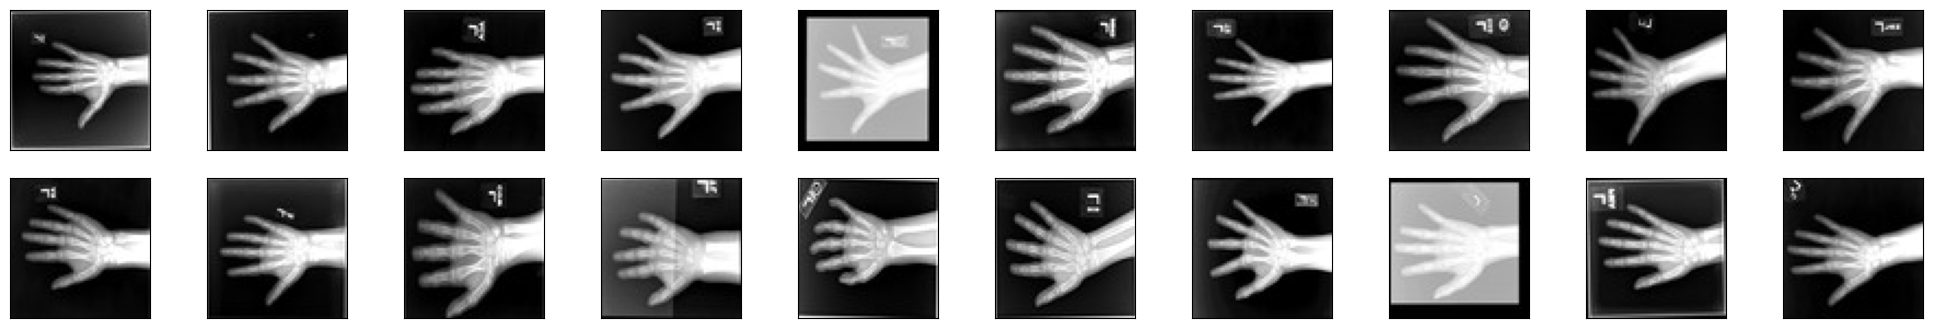

In [5]:
# obtain one batch of training images
dataiter_train = iter(train_loader)
batch = next(dataiter_train)
images = batch["image"]
images = images.numpy()
print(f"The image batch size is {images.shape}")

# plot the images in the batch, along with the corresponding labels
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')

### View an Image in More Detail

```
Run the cell below to display an image with the value of each pixel. This will enable you to check the operations performed by the transforms.Compose() function.
```

The size of an image from the dataset is (64, 64)


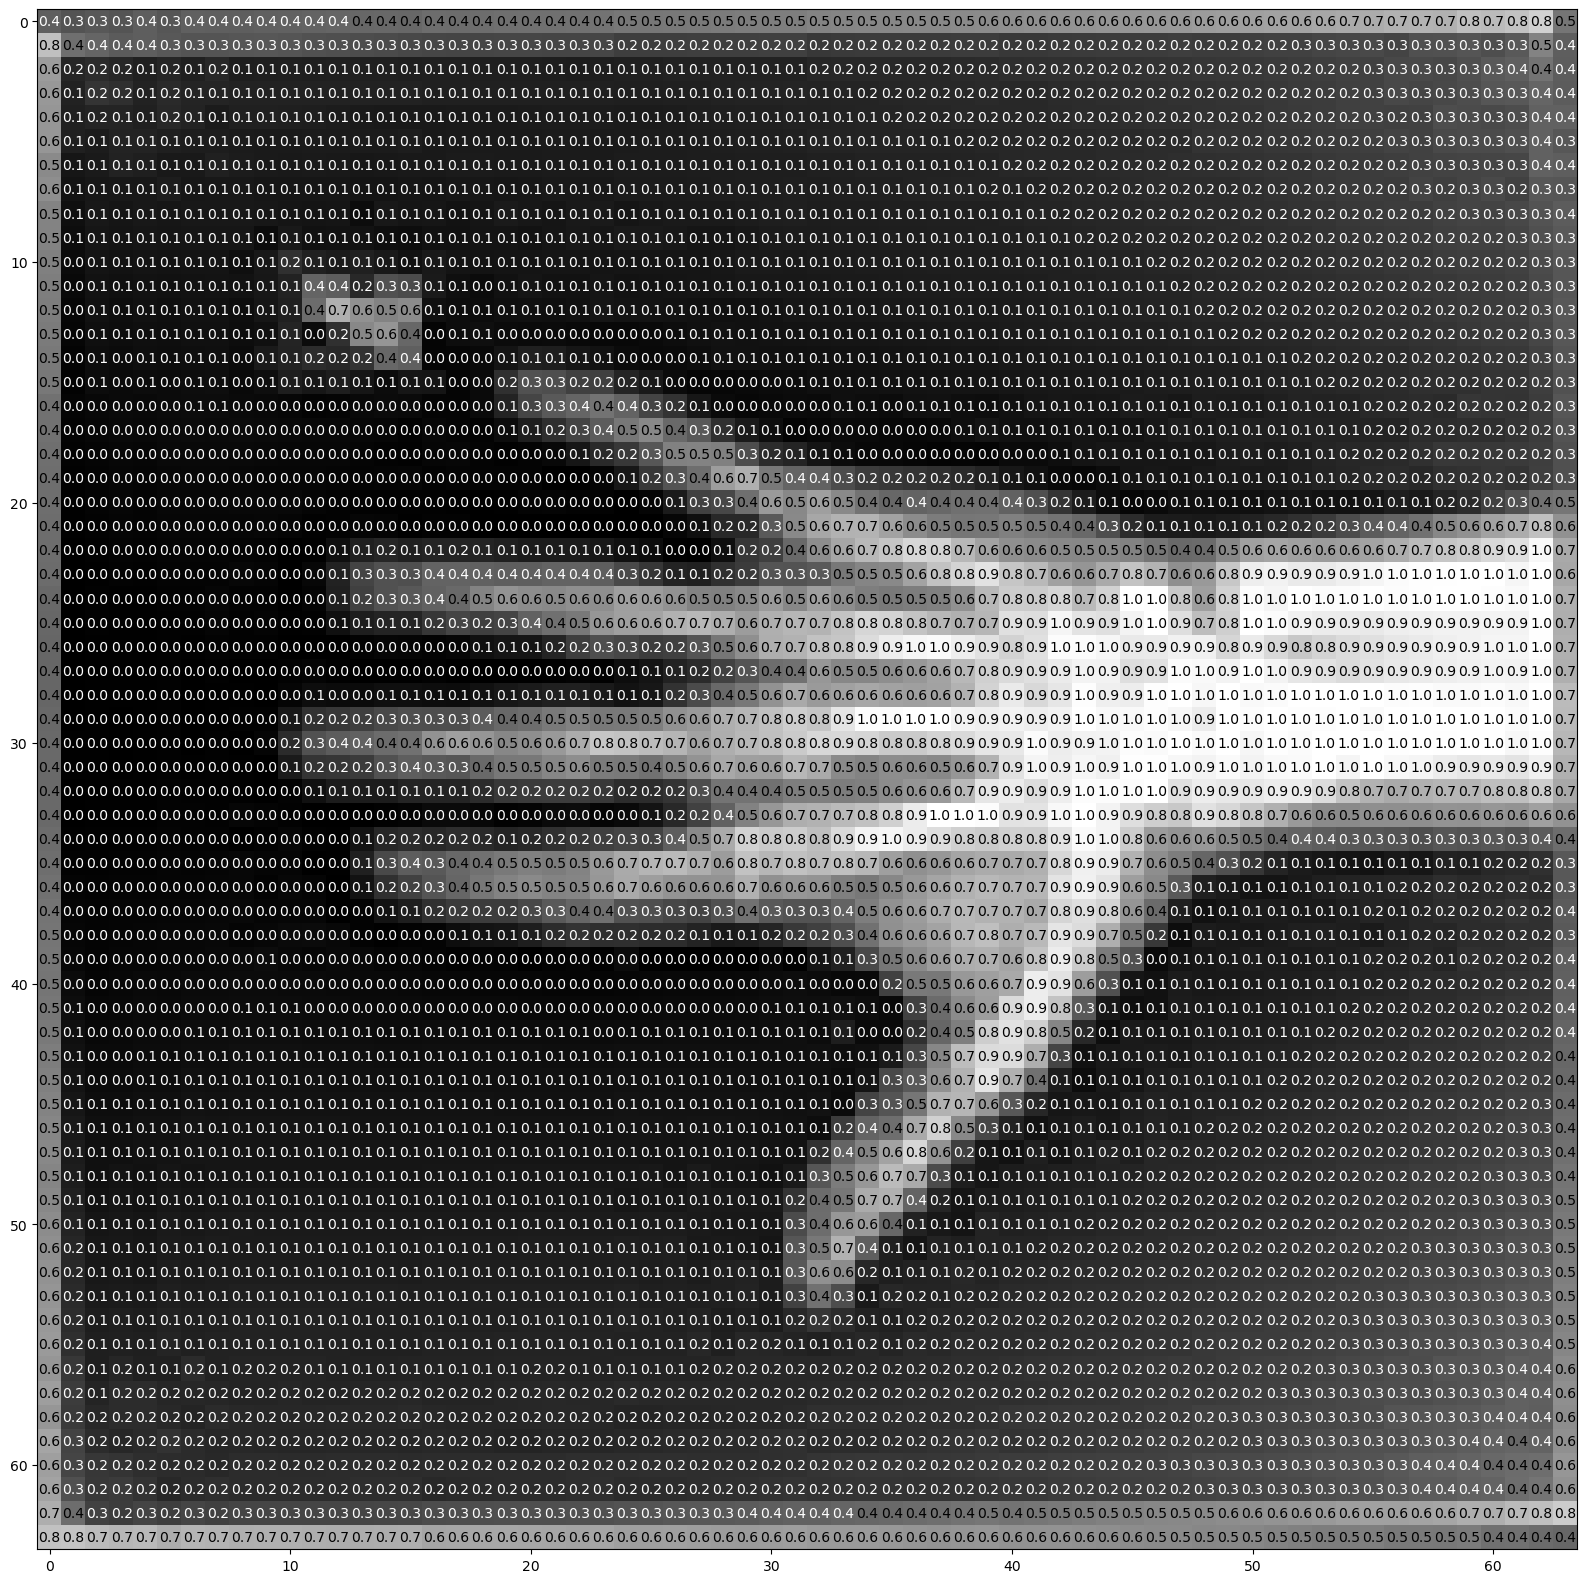

In [6]:
img = np.squeeze(images[0])
print(f"The size of an image from the dataset is {img.shape}")

fig = plt.figure(figsize = (20,20)) 
ax = fig.add_subplot(111)
ax.imshow(img, cmap='gray')
width, height = img.shape
thresh = img.max()/2.5
for x in range(width):
    for y in range(height):
        val = round(img[x][y],2) if img[x][y] !=0 else 0
        ax.annotate(f"{val:.1f}", xy=(y,x),
                    horizontalalignment='center',
                    verticalalignment='center',
                    color='white' if img[x][y]<thresh else 'black')

---
## Define the Network [Architecture](http://pytorch.org/docs/stable/nn.html)

Your turn!


J'ai crée une partie pour gerer les paramètres facilement.

In [ ]:
from dataclasses import field
import torch
import os, json

class MedNISTConfig:
    # ===== General =====
    seed: int = 42
    data_dir: str = "./data/MedNIST"
    download: bool = True
    save_dir: str = "./results_hands_opt"

    # ===== Data =====
    image_size: int = 128
    min_intensity: float = 0.0
    max_intensity: float = 1.0
    train_valid_ratio: float = 0.9
    batch_size: int = 64
    num_workers: int = 4
    persistent_workers: bool = True

    # ===== Model architecture =====
    latent_dim: int = 256
    encoder_channels = [1, 64, 128, 256, 512, 512]
    decoder_channels = [512, 512, 256, 128, 64, 1]
    kernel_size: int = 3
    stride: int = 2
    padding: int = 1
    activation: str = "LeakyReLU"
    output_activation: str = "Sigmoid"
    dropout_rate: float = 0.1
    use_batchnorm: bool = True

    # ===== Training =====
    num_epochs: int = 80         
    learning_rate: float = 2e-4 
    weight_decay: float = 1e-6
    loss_function: str = "MSELoss"  
    scheduler: str = "CosineAnnealingLR"

    # ===== Misc =====
    labels: list = field(default_factory=lambda: [
        'AbdomenCT', 'BreastMRI', 'ChestCT', 'CXR', 'Hand', 'HeadCT'
    ])
    selected_label: str = "Hand"
    device: torch.device = field(default_factory=lambda: torch.device("cuda" if torch.cuda.is_available() else "cpu"))



    # ===== Utils =====
    def summary(self):
        for key, value in self.__dict__.items():
            print(f"{key:20}: {value}")

    def save(self, filepath: str = None):
        if filepath is None:
            filepath = os.path.join(self.save_dir, "config.json")
        os.makedirs(os.path.dirname(filepath), exist_ok=True)
        with open(filepath, "w") as f:
            json.dump(self.__dict__, f, indent=4, default=str)


Model on device: cpu


# Approche 
J'ai décider de tester 3 approches une par VA, VAE, et une Par modèle pre-trained

Ensuite j'ai décider de tester un autoencodeur convolutionnel, j'ai decider d'utilser une convolutions pour exploiter la localisation spatiale de chaque élément 

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import random_split, DataLoader
from monai.apps import MedNISTDataset
from monai.data import Dataset
from monai.transforms import Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityRanged, Resized


# ======================================================
# Configuration
# ======================================================
cfg = MedNISTConfig()
os.makedirs(cfg.save_dir, exist_ok=True)
cfg.summary()
cfg.save()


# ======================================================
# Data Preparation
# ======================================================
train_set = MedNISTDataset(root_dir=cfg.data_dir, section="training", download=cfg.download, seed=cfg.seed)
test_set = MedNISTDataset(root_dir=cfg.data_dir, section="validation", download=cfg.download, seed=cfg.seed)

train_datalist = [{"image": item["image"], "label": cfg.selected_label}
                  for item in train_set.data if item["class_name"] == cfg.selected_label]
test_datalist = [{"image": item["image"], "label": cfg.selected_label}
                 for item in test_set.data if item["class_name"] == cfg.selected_label]

all_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    ScaleIntensityRanged(keys=["image"], a_min=0.0, a_max=255.0,
                         b_min=cfg.min_intensity, b_max=cfg.max_intensity, clip=True),
    Resized(keys=["image"], spatial_size=[cfg.image_size, cfg.image_size]),
])

train_dataset = Dataset(data=train_datalist, transform=all_transforms)
test_data = Dataset(data=test_datalist, transform=all_transforms)

train_size = int(cfg.train_valid_ratio * len(train_dataset))
valid_size = len(train_dataset) - train_size
train_data, valid_data = random_split(train_dataset, [train_size, valid_size])

train_loader = DataLoader(train_data, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, persistent_workers=cfg.persistent_workers)
valid_loader = DataLoader(valid_data, batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, persistent_workers=cfg.persistent_workers)
test_loader = DataLoader(test_data, batch_size=cfg.batch_size, shuffle=False,
                         num_workers=cfg.num_workers, persistent_workers=cfg.persistent_workers)


# ======================================================
# Model Definition
# ======================================================
class ConvAutoencoder(nn.Module):
    def __init__(self, cfg: MedNISTConfig):
        super().__init__()
        act_fn = getattr(nn, cfg.activation)

        # --- Encoder ---
        enc_layers = []
        for in_c, out_c in zip(cfg.encoder_channels[:-1], cfg.encoder_channels[1:]):
            enc_layers.append(nn.Conv2d(in_c, out_c, cfg.kernel_size, cfg.stride, cfg.padding))
            if cfg.use_batchnorm:
                enc_layers.append(nn.BatchNorm2d(out_c))
            enc_layers.append(act_fn(inplace=True))
            enc_layers.append(nn.Dropout2d(cfg.dropout_rate))
        self.encoder = nn.Sequential(*enc_layers)

        # Compute final encoder output shape dynamically
        with torch.no_grad():
            dummy = torch.zeros(1, 1, cfg.image_size, cfg.image_size)
            out = self.encoder(dummy)
            self.enc_shape = out.shape[1:]  # (C, H, W)
            self.enc_flat = int(np.prod(self.enc_shape))

        # --- Latent space ---
        self.fc1 = nn.Linear(self.enc_flat, cfg.latent_dim)
        self.fc2 = nn.Linear(cfg.latent_dim, self.enc_flat)

        # --- Decoder ---
        dec_layers = []
        for in_c, out_c in zip(cfg.decoder_channels[:-1], cfg.decoder_channels[1:]):
            dec_layers.append(nn.ConvTranspose2d(in_c, out_c, cfg.kernel_size, cfg.stride, cfg.padding))
            if out_c != 1:
                if cfg.use_batchnorm:
                    dec_layers.append(nn.BatchNorm2d(out_c))
                dec_layers.append(act_fn(inplace=True))
                dec_layers.append(nn.Dropout2d(cfg.dropout_rate))
            else:
                dec_layers.append(getattr(nn, cfg.output_activation)())
        self.decoder = nn.Sequential(*dec_layers)

    def forward(self, x):
        orig_size = x.shape[-2:]  # (H, W)
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        z = self.fc1(x)
        x = self.fc2(z)
        x = x.view(x.size(0), *self.enc_shape)
        x = self.decoder(x)

        # Force final output to match input spatial size
        if x.shape[-2:] != orig_size:
            x = nn.functional.interpolate(x, size=orig_size, mode="bilinear", align_corners=False)
        return x



# ======================================================
# Training Setup
# ======================================================
device = cfg.device
model = ConvAutoencoder(cfg).to(device)
criterion = getattr(nn, cfg.loss_function)()
optimizer = optim.AdamW(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.num_epochs)

# Early stopping parameters
patience = 10
best_val_loss = np.inf
epochs_no_improve = 0
checkpoint_path = os.path.join(cfg.save_dir, "best_model.pth")


# ======================================================
# Training Loop
# ======================================================
train_losses, valid_losses = [], []

print("\n Start training...\n")
for epoch in range(cfg.num_epochs):
    model.train()
    train_loss = 0.0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.num_epochs}"):
        imgs = batch["image"].to(device).float()
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, imgs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in valid_loader:
            imgs = batch["image"].to(device).float()
            outputs = model(imgs)
            loss = criterion(outputs, imgs)
            val_loss += loss.item() * imgs.size(0)
    val_loss /= len(valid_loader.dataset)
    scheduler.step()

    train_losses.append(train_loss)
    valid_losses.append(val_loss)
    print(f"Epoch [{epoch+1}/{cfg.num_epochs}]  Train: {train_loss:.6f}  Val: {val_loss:.6f}")

    # --- Early Stopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), checkpoint_path)
        print(f"Validation loss improved. Model saved to {checkpoint_path}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\n⏹ Early stopping at epoch {epoch+1}. Best val loss: {best_val_loss:.6f}")
            break


# ======================================================
# Plot Training Curve
# ======================================================
plt.figure(figsize=(6,4))
plt.plot(train_losses, label='Train')
plt.plot(valid_losses, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.title('Autoencoder Training Curve')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(cfg.save_dir, "training_curve.png"))
plt.close()
print(f"Training curve saved to {cfg.save_dir}/training_curve.png")


# ======================================================
# Reconstruction Visualization
# ======================================================
def show_reconstructions(model, loader, n=8):
    model.eval()
    imgs = next(iter(loader))["image"][:n].to(device)
    with torch.no_grad():
        recs = model(imgs)
    imgs, recs = imgs.cpu().numpy(), recs.cpu().numpy()

    fig, axes = plt.subplots(2, n, figsize=(15, 4))
    for i in range(n):
        axes[0, i].imshow(np.squeeze(imgs[i]), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title("Original")

        axes[1, i].imshow(np.squeeze(recs[i]), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title("Reconstructed")

    plt.tight_layout()
    plt.show()
    plt.savefig(os.path.join(cfg.save_dir, "reconstructions.png"))
    plt.close()
    print(f"Reconstructions saved to {cfg.save_dir}/reconstructions.png")


# ======================================================
# Load Best Model & Evaluate
# ======================================================
print("\nLoading best model and generating reconstructions...")
model.load_state_dict(torch.load(checkpoint_path))
show_reconstructions(model, test_loader)
print("\nTraining complete. Best validation loss:", round(best_val_loss, 6))


Epoch 1/25: 100%|█████████████████████████████| 100/100 [00:38<00:00,  2.63it/s]
/usr/local/anaconda3/lib/python3.11/site-packages/transformers/utils/generic.py:260: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/usr/local/anaconda3/lib/python3.11/site-packages/transformers/utils/generic.py:260: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/usr/local/anaconda3/lib/python3.11/site-packages/transformers/utils/generic.py:260: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/usr/local/anaconda3/lib/python3.11/site-packages/transformers/utils/generic.py:260: UserWarning: torch.utils._pytree._register_pytree_n

Epoch [1/25]  Train Loss: 0.046637  Val Loss: 0.025998


Epoch 2/25: 100%|█████████████████████████████| 100/100 [00:52<00:00,  1.89it/s]


Epoch [2/25]  Train Loss: 0.021368  Val Loss: 0.017628


Epoch 3/25: 100%|█████████████████████████████| 100/100 [00:52<00:00,  1.89it/s]


...

Epoch [23/25]  Train Loss: 0.003468  Val Loss: 0.004271


Epoch 24/25: 100%|████████████████████████████| 100/100 [01:14<00:00,  1.34it/s]


Epoch [24/25]  Train Loss: 0.003389  Val Loss: 0.004227


Epoch 25/25: 100%|████████████████████████████| 100/100 [01:10<00:00,  1.43it/s]


Epoch [25/25]  Train Loss: 0.003383  Val Loss: 0.004094


Nous avons de bons résultats, avec le modèle autoencodeur convolutionnel, mais il reste encore flou sans trops de détail le j'ai tester avec différents paramètres et celà sont les meilleurs que j'ai obtenue avec un tempt de calcul pas très long environ 45min

Technique Par VAE

Ensuite 




In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import random_split, DataLoader
from monai.apps import MedNISTDataset
from monai.data import Dataset
from monai.transforms import Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityRanged, Resized


# ======================================================
# Configuration
# ======================================================
cfg = MedNISTConfig()
os.makedirs(cfg.save_dir, exist_ok=True)
cfg.summary()
cfg.save()


# ======================================================
# Data Preparation
# ======================================================
train_set = MedNISTDataset(root_dir=cfg.data_dir, section="training", download=cfg.download, seed=cfg.seed)
test_set = MedNISTDataset(root_dir=cfg.data_dir, section="validation", download=cfg.download, seed=cfg.seed)

train_datalist = [{"image": item["image"], "label": cfg.selected_label}
                  for item in train_set.data if item["class_name"] == cfg.selected_label]
test_datalist = [{"image": item["image"], "label": cfg.selected_label}
                 for item in test_set.data if item["class_name"] == cfg.selected_label]

all_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    ScaleIntensityRanged(keys=["image"], a_min=0.0, a_max=255.0,
                         b_min=cfg.min_intensity, b_max=cfg.max_intensity, clip=True),
    Resized(keys=["image"], spatial_size=[cfg.image_size, cfg.image_size]),
])

train_dataset = Dataset(data=train_datalist, transform=all_transforms)
test_data = Dataset(data=test_datalist, transform=all_transforms)

train_size = int(cfg.train_valid_ratio * len(train_dataset))
valid_size = len(train_dataset) - train_size
train_data, valid_data = random_split(train_dataset, [train_size, valid_size])

train_loader = DataLoader(train_data, batch_size=cfg.batch_size, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=cfg.batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=cfg.batch_size, shuffle=False)


# ======================================================
# Model Definition
# ======================================================
class ConvVAE(nn.Module):
    def __init__(self, cfg: MedNISTConfig):
        super().__init__()
        act_fn = getattr(nn, cfg.activation)

        # --- Encoder ---
        enc_layers = []
        for in_c, out_c in zip(cfg.encoder_channels[:-1], cfg.encoder_channels[1:]):
            enc_layers.append(nn.Conv2d(in_c, out_c, cfg.kernel_size, cfg.stride, cfg.padding))
            enc_layers.append(nn.BatchNorm2d(out_c))
            enc_layers.append(act_fn(inplace=True))
        self.encoder = nn.Sequential(*enc_layers)

        with torch.no_grad():
            dummy = torch.zeros(1, 1, cfg.image_size, cfg.image_size)
            out = self.encoder(dummy)
            self.enc_shape = out.shape[1:]
            self.enc_flat = int(np.prod(self.enc_shape))

        # Latent space
        self.fc_mu = nn.Linear(self.enc_flat, cfg.latent_dim)
        self.fc_logvar = nn.Linear(self.enc_flat, cfg.latent_dim)
        self.fc_decode = nn.Linear(cfg.latent_dim, self.enc_flat)

        # --- Decoder ---
        dec_layers = []
        for in_c, out_c in zip(cfg.decoder_channels[:-1], cfg.decoder_channels[1:]):
            dec_layers.append(nn.ConvTranspose2d(in_c, out_c, cfg.kernel_size, cfg.stride, cfg.padding))
            if out_c != 1:
                dec_layers.append(nn.BatchNorm2d(out_c))
                dec_layers.append(act_fn(inplace=True))
            else:
                dec_layers.append(nn.Sigmoid())  # Output in [0,1]
        self.decoder = nn.Sequential(*dec_layers)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        orig_size = x.shape[-2:]
        x = self.encoder(x)
        x = x.view(x.size(0), -1)

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        z = self.reparameterize(mu, logvar)

        x = self.fc_decode(z)
        x = x.view(x.size(0), *self.enc_shape)
        x = self.decoder(x)

        if x.shape[-2:] != orig_size:
            x = nn.functional.interpolate(x, size=orig_size, mode="bilinear", align_corners=False)

        return x, mu, logvar


# ======================================================
# Loss Function
# ======================================================
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction="sum")
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return (recon_loss + cfg.beta * kld) / x.size(0)


# ======================================================
# Training Setup
# ======================================================
device = cfg.device
model = ConvVAE(cfg).to(device)
optimizer = optim.AdamW(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.num_epochs)

best_val_loss = np.inf
epochs_no_improve = 0
patience = 10
checkpoint_path = os.path.join(cfg.save_dir, "best_vae.pth")

train_losses, valid_losses = [], []

print("\n Starting VAE training...\n")
for epoch in range(cfg.num_epochs):
    model.train()
    train_loss = 0.0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.num_epochs}"):
        imgs = batch["image"].to(device).float()
        optimizer.zero_grad()
        outputs, mu, logvar = model(imgs)
        loss = vae_loss(outputs, imgs, mu, logvar)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in valid_loader:
            imgs = batch["image"].to(device).float()
            outputs, mu, logvar = model(imgs)
            loss = vae_loss(outputs, imgs, mu, logvar)
            val_loss += loss.item() * imgs.size(0)
    val_loss /= len(valid_loader.dataset)
    scheduler.step()

    train_losses.append(train_loss)
    valid_losses.append(val_loss)
    print(f"Epoch [{epoch+1}/{cfg.num_epochs}]  Train: {train_loss:.6f}  Val: {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), checkpoint_path)
        print(f"Validation improved. Saved model to {checkpoint_path}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\n Early stopping at epoch {epoch+1}. Best val loss: {best_val_loss:.6f}")
            break


# ======================================================
# Visualization
# ======================================================
plt.figure(figsize=(6,4))
plt.plot(train_losses, label='Train')
plt.plot(valid_losses, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('VAE Loss')
plt.legend()
plt.title('VAE Training Curve')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(cfg.save_dir, "vae_training_curve.png"))
plt.close()


def show_reconstructions(model, loader, n=8):
    model.eval()
    imgs = next(iter(loader))["image"][:n].to(device)
    with torch.no_grad():
        recs, _, _ = model(imgs)
    imgs, recs = imgs.cpu().numpy(), recs.cpu().numpy()
    fig, axes = plt.subplots(2, n, figsize=(15, 4))
    for i in range(n):
        axes[0, i].imshow(np.squeeze(imgs[i]), cmap='gray')
        axes[1, i].imshow(np.squeeze(recs[i]), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].axis('off')
        if i == 0:
            axes[0, i].set_title("Original")
            axes[1, i].set_title("Reconstructed")
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.save_dir, "vae_reconstructions.png"))
    plt.close()


print("\n Loading best VAE and generating reconstructions...")
model.load_state_dict(torch.load(checkpoint_path))
show_reconstructions(model, test_loader)
print("\n VAE training complete. Best validation loss:", round(best_val_loss, 6))


Troisième méthode les modèles pre-trained ceux avec le meilleurs résultats mais aussi la plus grande rapiditée d'entrainement